In [44]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
load_dotenv()
# DATASET_PATH=os.getenv("DATASET_DIRECTORY")
DATASET_PATH="/data/RadVel"
CONFIG_DIRECTORY = os.getenv("CONFIG_DIRECTORY")

sys.path.append("../")
from mmwave_radar_processing.config_managers.cfgManager import ConfigManager
from cpsl_datasets.cpsl_ds import CpslDS
from mmwave_radar_processing.processors.range_angle_resp import RangeAngleProcessor
from mmwave_radar_processing.processors.range_doppler_resp import RangeDopplerProcessor
from mmwave_radar_processing.processors.doppler_azimuth_resp import DopplerAzimuthProcessor
from mmwave_radar_processing.processors.micro_doppler_resp import MicroDopplerProcessor
from mmwave_radar_processing.processors.virtual_array_reformater import VirtualArrayReformatter
from mmwave_radar_processing.plotting.plotter_mmWave_data import PlotterMmWaveData
from mmwave_radar_processing.plotting.movies_mmWave_data import MovieGeneratorMmWaveData


In [45]:
cfg_manager = ConfigManager()

cfg_path = os.path.join(CONFIG_DIRECTORY,"6843_RadVel_ods_20Hz.cfg")
cfg_manager.load_cfg(cfg_path,array_geometry="ods",array_direction="down")
cfg_manager.compute_radar_perforance(profile_idx=0)
cfg_manager.print_cfg_overview()

---- Radar Configuration Overview ----
Radar Performance
	range res: 0.06m
	range max: 3.93m
	vel res: 0.06m/s
	vel max: 2.15m/s
Profile Configuration:
	profile config: 
	{'profileId': 0, 'startFreq_GHz': 60.0, 'idleTime_us': 150.0, 'adcStartTime_us': 7.0, 'rampEndTime_us': 44.0, 'txOutPower': 0.0, 'txPhaseShifter': 0.0, 'freqSlope_MHz_us': 80.0, 'txStartTime_us': 1.0, 'adcSamples': 63, 'sampleRate_kSps': 2100, 'hpfCornerFreq1': 0, 'hpfCornerFreq2': 0, 'rxGain_dB': 158.0}
	Frame loops: 70
	Chirp period: 194.0 us
	Active frame time: 40.74 ms
	Frame period: 50.0
	Antenna Geometry: ods
	Operating Frequency: 60.0 GHz


In [46]:
#load the dataset
dataset_name = "CPSL_RadVel_ods_20Hz_1"
dataset_path = os.path.join(DATASET_PATH,dataset_name)
print(dataset_path)
# dataset_name = "RadSAR_2_CPSL"
# dataset_path = os.path.join(DATASET_PATH,os.pardir,"RadSAR",dataset_name)
dataset = CpslDS(
    dataset_path=dataset_path,
    radar_adc_folder="radar_0_adc", #or "front_radar"
    lidar_folder="lidar",
    camera_folder="camera",
    hand_tracking_folder="hand_tracking",
    imu_orientation_folder="imu_orientation", #not implemented
    imu_full_folder="imu_data",
    vehicle_vel_folder="vehicle_vel",
    vehicle_odom_folder="vehicle_odom"
)

/data/RadVel/CPSL_RadVel_ods_20Hz_1
found 806 radar ADC samples
did not find lidar samples
did not find camera samples
did not find hand tracking samples
did not find imu (orientation) samples
did not find imu (full data) samples
found 806 vehicle velocity samples
found 806 vehicle odometry samples


In [47]:
#load the plotter
plotter = PlotterMmWaveData(config_manager=cfg_manager)

#initialize a range azimuth processor
range_az_processor = RangeAngleProcessor(
    config_manager=cfg_manager,
    num_angle_bins=64
)

#initialize the range doppler processor
range_doppler_processor = RangeDopplerProcessor(
    config_manager=cfg_manager
)

doppler_azimuth_processor = DopplerAzimuthProcessor(
    config_manager=cfg_manager,
    num_angle_bins=64
)

micro_doppler_processor = MicroDopplerProcessor(
    config_manager=cfg_manager,
    target_ranges=np.array([3.0,3.7]),
    num_frames_history=20
)

#load the ADC data reformatter
virtual_array_reformatter = VirtualArrayReformatter(config_manager=cfg_manager)

#initialize the movie generator
movie_generator = MovieGeneratorMmWaveData(
    cpsl_dataset=dataset,
    plotter=plotter,
    range_azimuth_processor=range_az_processor,
    range_doppler_processor=range_doppler_processor,
    doppler_azimuth_processor=doppler_azimuth_processor,
    micro_doppler_processor=micro_doppler_processor,
    virtual_array_reformatter=virtual_array_reformatter,
    temp_dir_path=os.path.join("~/Downloads/RadVel",dataset_name)
)

found temp dir: /home/david/Downloads/RadVel/CPSL_RadVel_ods_20Hz_1
clearing temp directory /home/david/Downloads/RadVel/CPSL_RadVel_ods_20Hz_1


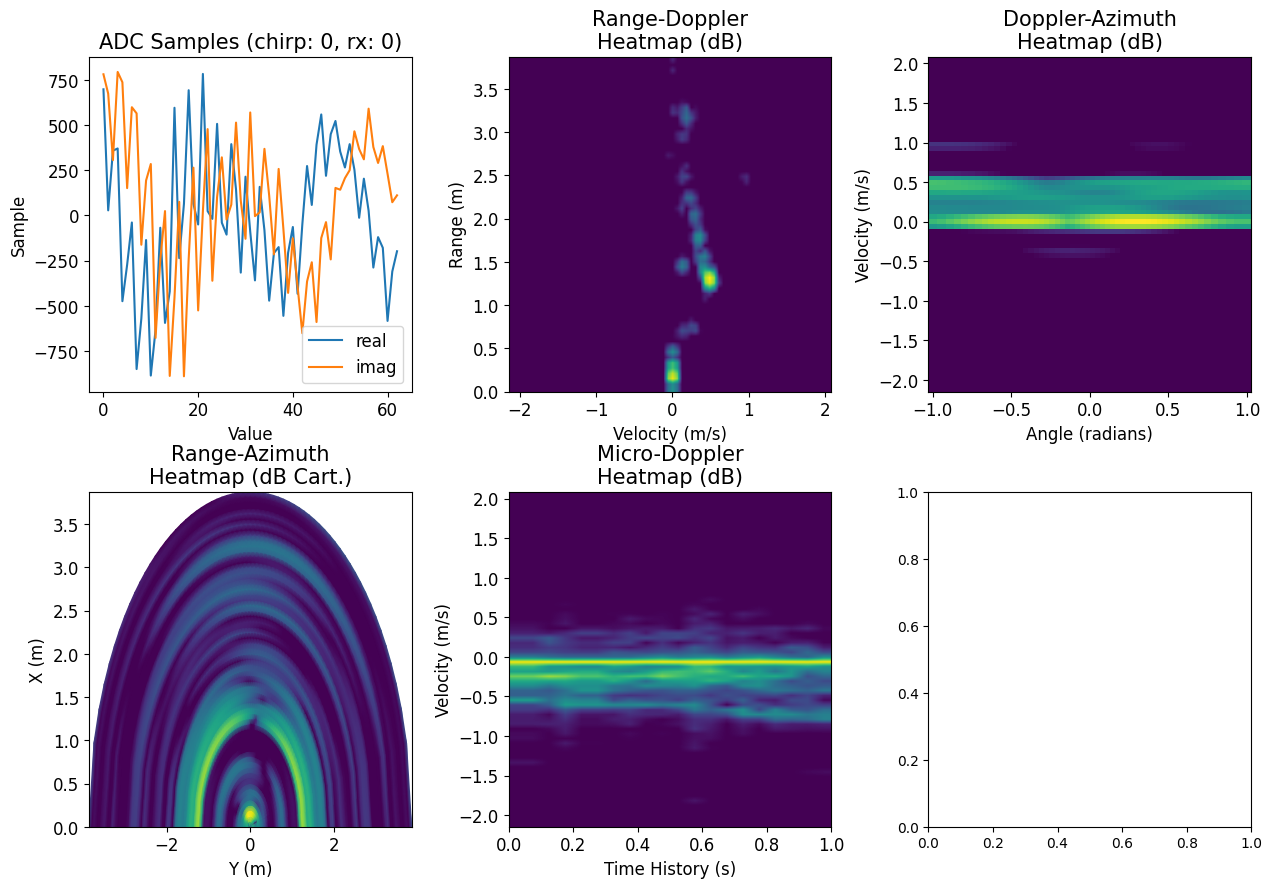

In [48]:
#for getting access to the adc cube
idx=158 - micro_doppler_processor.num_frames_history
#compute responses over a series of frames
for i in range(micro_doppler_processor.num_frames_history):

    #get the ADC cube
    adc_cube = dataset.get_radar_adc_data(idx + i)

    adc_cube = virtual_array_reformatter.process(adc_cube)
    rng_az_resp = range_az_processor.process(adc_cube=adc_cube,chirp_idx=0)
    rng_dop_resp = range_doppler_processor.process(adc_cube=adc_cube,rx_idx=0)
    dop_az_resp = doppler_azimuth_processor.process(adc_cube=adc_cube)
    micro_doppler_resp = micro_doppler_processor.process(adc_cube=adc_cube,rx_idx=0)

    try:
        camera_view = dataset.get_camera_frame(idx + i)
    except AssertionError:
        camera_view = np.empty(shape=(0))

#for generating a compilation of plots
fig,axs=plt.subplots(2,3, figsize=(15,10))
fig.subplots_adjust(wspace=0.3,hspace=0.30)

plotter.plot_compilation(
    adc_cube=adc_cube,
    range_doppler_processor=range_doppler_processor,
    range_azimuth_processor=range_az_processor,
    doppler_azimuth_processor=doppler_azimuth_processor,
    micro_doppler_processor=micro_doppler_processor,
    camera_view=camera_view,
    convert_to_dB=True,
    cmap="viridis",
    chirp_idx=0,
    rx_antenna_idx=0,
    axs=axs,
    show=True
)

In [49]:
# #generate the movie - initialize the figure
# movie_generator.initialize_figure(nrows=2,ncols=3,figsize=(15,10))

# #reset the microdoppler signature
# movie_generator.micro_doppler_processor.micro_doppler_resp = np.zeros_like(movie_generator.micro_doppler_processor.micro_doppler_resp)

# #generate the movie frames
# movie_generator.generate_movie_frames(
#     chirp_idx=0,
#     rx_antenna_idx=0,
#     cmap="viridis",
#     convert_to_dB=True
# )

# fps = 1 / (1e-3 * cfg_manager.frameCfg_periodicity_ms)
# movie_generator.save_movie(video_file_name="{}_raw.mp4".format(dataset_name),fps=fps)

In [50]:
#initialize a range processor
from mmwave_radar_processing.processors.range_resp import RangeProcessor

range_processor = RangeProcessor(
    config_manager=cfg_manager
)

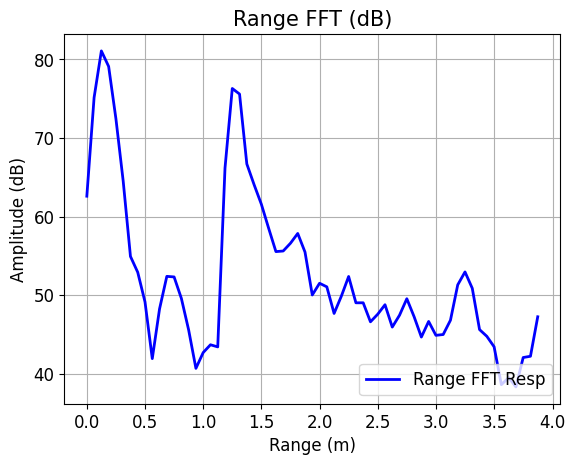

In [51]:
#get the ADC cube
adc_cube = dataset.get_radar_adc_data(idx + i)

adc_cube = virtual_array_reformatter.process(adc_cube)

rng_resp = range_processor.process(
    adc_cube=adc_cube,
    chirp_idx=0
)

plotter.plot_range_resp(
    resp=rng_resp,
    rng_bins=range_processor.range_bins,
    convert_to_dB=True,
    show=True
)

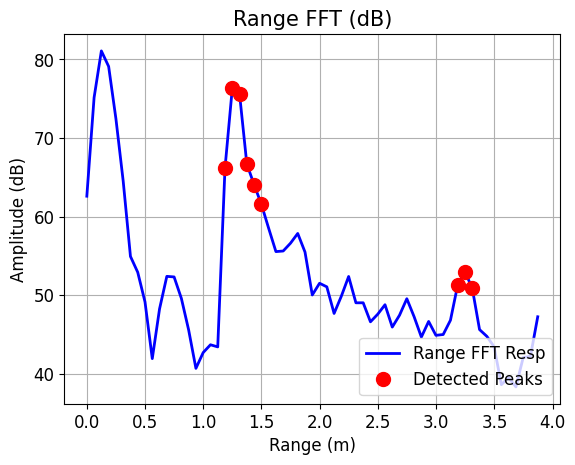

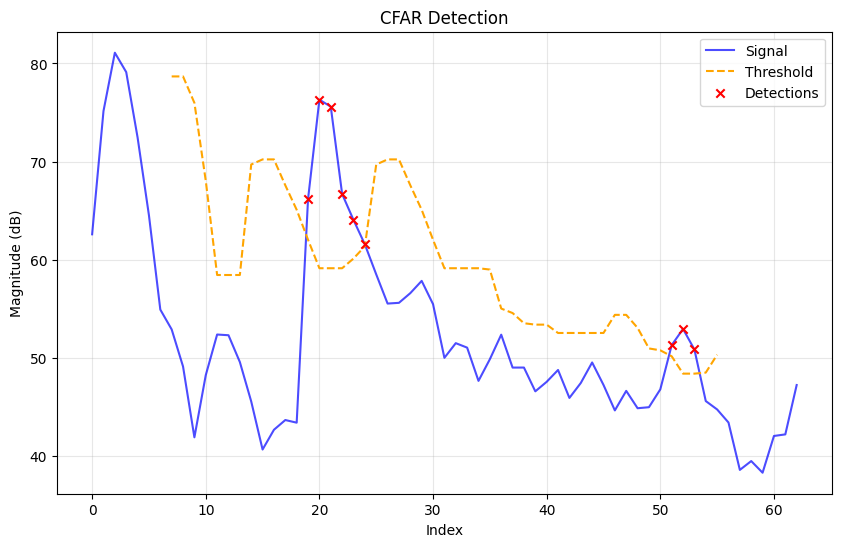

[19, 20, 21, 22, 23, 24, 51, 52, 53]


In [52]:
from mmwave_radar_processing.detectors import CaCFAR1D, GoCFAR1D, SoCFAR1D, OsCFAR1D

rho = 0.75
num_train = 4
k_rank = int(rho * num_train * 2)
ca_cfar_1d = OsCFAR1D(
    num_train=num_train,
    num_guard=3,
    k_rank=k_rank,
    alpha=1.5
)

dets = ca_cfar_1d.detect(
    rng_resp
)
peak_rng_bins = range_processor.range_bins[dets]
peak_vals = 20*np.log10(rng_resp[dets])

plotter.plot_range_resp(
    resp=rng_resp,
    rng_bins=range_processor.range_bins,
    peak_rng_bins=peak_rng_bins,
    peak_vals=peak_vals,
    convert_to_dB=True,
    show=True
)

ca_cfar_1d.plot_detections(
    x=rng_resp,
    convert_to_dB=True
)
print(dets)

num_dets (CA-CFAR-2D): 53


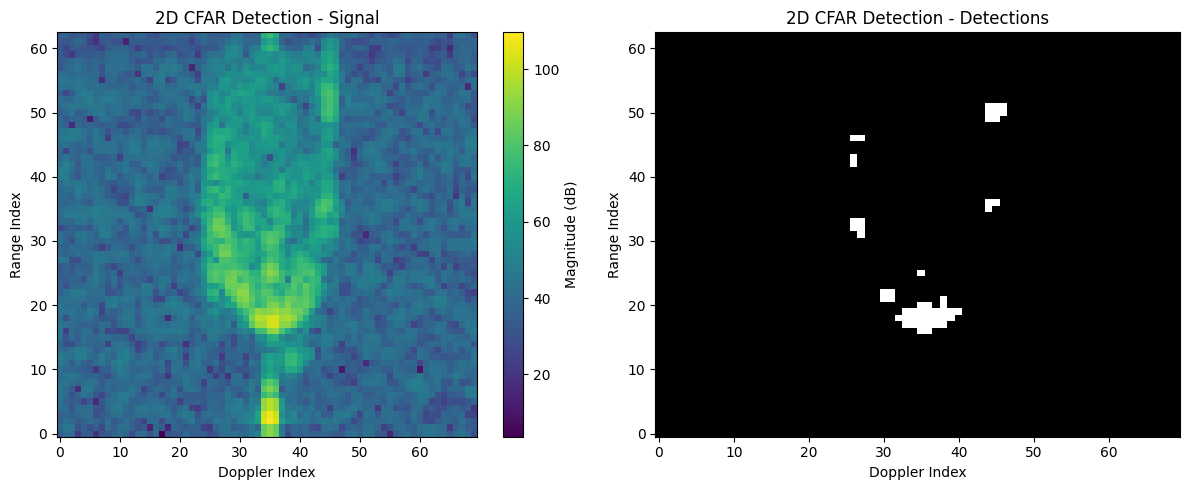

num_dets (OS-CFAR-2D): 56


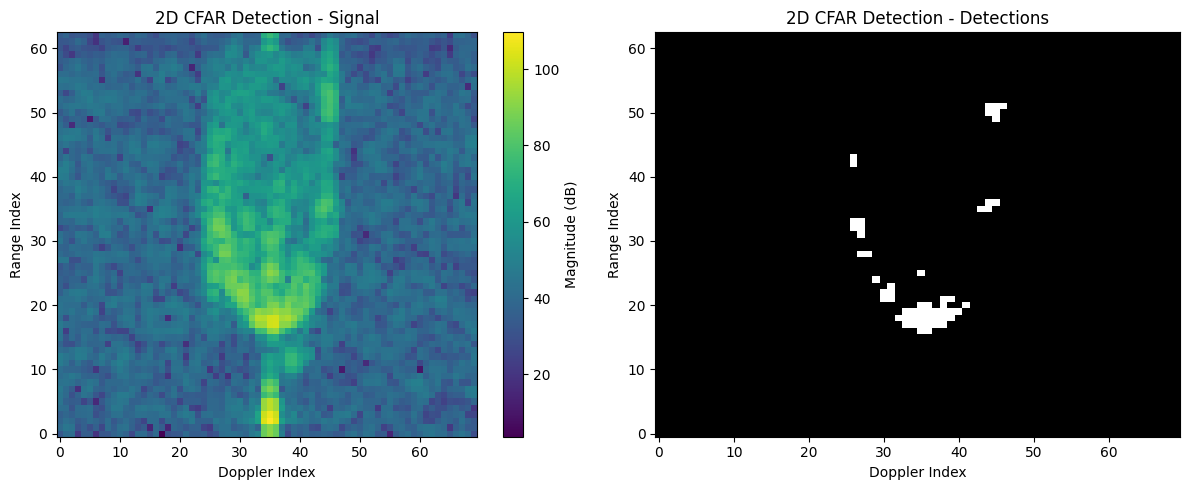

In [70]:
from mmwave_radar_processing.detectors import CaCFAR2D,  OsCFAR2D

idx = 296

adc_cube = dataset.get_radar_adc_data(idx)

adc_cube = virtual_array_reformatter.process(adc_cube)

rng_dop_resp_raw = range_doppler_processor.process(
    adc_cube=adc_cube,
    rx_idx=-1,
    return_magnitude=False)

rng_dop_resp = np.abs(rng_dop_resp_raw[0,:,:])

num_train = (7,7)
num_guard = (4,4)

ca_cfar_2d = CaCFAR2D(
    num_train=num_train,
    num_guard=num_guard,
    pfa=1e-2
)

rho = 0.8
N_train_window = (2 * (num_train[0] + num_guard[0])) * (2 * (num_train[1] + num_guard[1]))
N_guard_window = (2 * num_guard[0]) * (2 * num_guard[1])
N_train_cells = N_train_window - N_guard_window - 1
k_rank = int(rho * N_train_cells)

os_cfar_2d = OsCFAR2D(
    num_train=num_train,
    num_guard=num_guard,
    k_rank=k_rank,
    alpha=5
)

dets = ca_cfar_2d.detect(rng_dop_resp)
print(f"num_dets (CA-CFAR-2D): {len(dets)}")
ca_cfar_2d.plot_detections(
    X=rng_dop_resp,
    convert_to_dB=True
)

dets = os_cfar_2d.detect(rng_dop_resp)
print(f"num_dets (OS-CFAR-2D): {len(dets)}")
os_cfar_2d.plot_detections(
    X=rng_dop_resp,
    convert_to_dB=True
)


In [77]:
#initialize angle bins
num_angle_bins = 64
num_rx_antennas = cfg_manager.num_rx_antennas
phase_shifts = np.arange(
    start=np.pi,
    stop= -np.pi - 2 * np.pi/(num_angle_bins - 1),
    step=-2 * np.pi / (num_angle_bins - 1)
)

#round the last entry to be exactly pi
phase_shifts[-1] = -1 * np.pi

#compute the angle bins
angle_bins = np.arcsin(phase_shifts / np.pi)

Strongest detection - Range: 1.06 m, Velocity: 0.06 m/s, Magnitude: 140440.38
Detected Target (x,y,z,v): [ 1.0293957  -0.18253977  0.18538753  0.0613223 ]  (m, m/s)
Detected Azimuth Angle: -10.06 degrees
Detected Elevation Angle: 10.06 degrees


Text(0, 0.5, 'Magnitude')

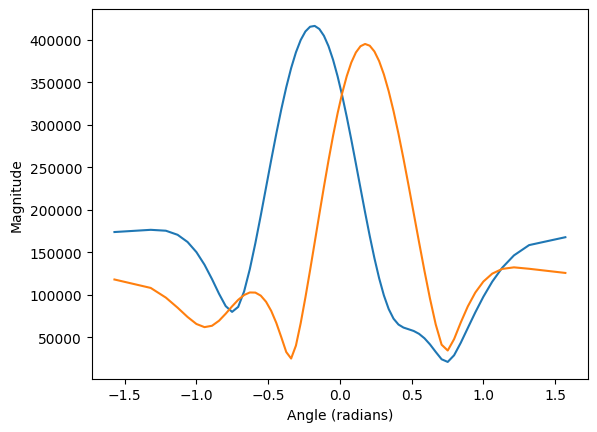

In [102]:
#now, take the detections and map them to range and velocity
dets = np.array(dets)

#get the detection indicies
det_range_idxs = dets[:,0]
det_velocity_idxs = dets[:,1]

#combine to correlate with range and velocity bins
det_ranges = range_doppler_processor.range_bins[det_range_idxs]
det_velocities = range_doppler_processor.vel_bins[det_velocity_idxs]
det_mags = rng_dop_resp[det_range_idxs, det_velocity_idxs]

#combine into a single array of (range, velocity, magnitude)
detections = np.column_stack((det_ranges, det_velocities, det_mags))

max_det_idx = np.argmax(detections[:,2])
print(f"Strongest detection - Range: {detections[max_det_idx,0]:.2f} m, Velocity: {detections[max_det_idx,1]:.2f} m/s, Magnitude: {detections[max_det_idx,2]:.2f}")

#get the rx_antennas corresponding to azimuth
az_antenna_idxs = np.array([0,3,4,7])
el_antenna_idxs = np.array([9,8,5,4])

#get the raw azimuth data for from the az antennas range doppler response
az_rng_dop_resp_raw = rng_dop_resp_raw[az_antenna_idxs,:,:]
el_rng_dop_resp_raw = rng_dop_resp_raw[el_antenna_idxs,:,:]

#next, compute the azimuth fft for a specific target
az_det_raw_data = np.zeros(shape=num_angle_bins,dtype=complex)
el_det_raw_data = np.zeros(shape=num_angle_bins,dtype=complex)

idx = max_det_idx
rng_idx = det_range_idxs[idx]
vel_idx = det_velocity_idxs[idx]

az_det_raw_data[0:az_antenna_idxs.shape[0]] =\
      az_rng_dop_resp_raw[:,rng_idx,vel_idx]
el_det_raw_data[0:el_antenna_idxs.shape[0]] =\
      el_rng_dop_resp_raw[:,rng_idx,vel_idx]

#compute the azimuth and ffts
az_resp = np.abs(
    np.fft.fftshift(
        x=np.fft.fft(az_det_raw_data)
    ))
# el_resp = np.abs(
#     np.fft.fftshift(
#         x=np.fft.fft(el_det_raw_data)
#     ))
el_resp = np.abs(
        np.fft.fft(el_det_raw_data)
    )

#get the corresponding angles
az_angle = angle_bins[np.argmax(az_resp)]
el_angle = angle_bins[np.argmax(el_resp)]

#save the detection's rho,theta (elevation), phi (azimuth), velocity)
det_spherical = np.array([
    det_ranges[idx],
    el_angle,
    az_angle,
    det_velocities[idx]
])


det_cartesian = np.array([
    det_spherical[0] * np.cos(det_spherical[1]) * np.cos(det_spherical[2]),
    det_spherical[0] * np.cos(det_spherical[1]) * np.sin(det_spherical[2]),
    det_spherical[0] * np.sin(det_spherical[1]),
    det_spherical[3]    
])
print(f"Detected Target (x,y,z,v): {det_cartesian}  (m, m/s)")
print(f"Detected Azimuth Angle: {np.degrees(az_angle):.2f} degrees")
print(f"Detected Elevation Angle: {np.degrees(el_angle):.2f} degrees")

plt.plot(angle_bins, az_resp)
plt.plot(angle_bins, el_resp)
plt.xlabel("Angle (radians)")
plt.ylabel("Magnitude")

Strongest detection - Range: 1.06 m, Velocity: 0.06 m/s, Magnitude: 140440.38


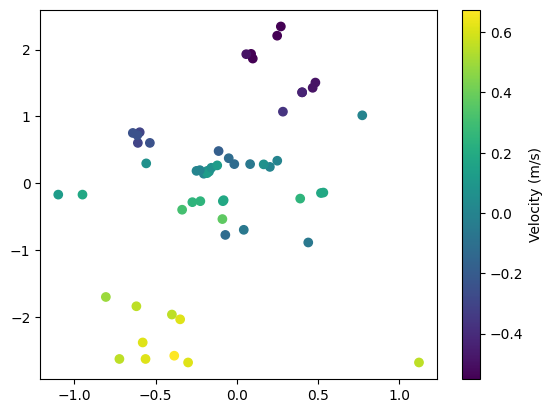

In [98]:
#now, take the detections and map them to range and velocity
dets = np.array(dets)

#get the detection indicies
det_range_idxs = dets[:,0]
det_velocity_idxs = dets[:,1]

#combine to correlate with range and velocity bins
det_ranges = range_doppler_processor.range_bins[det_range_idxs]
det_velocities = range_doppler_processor.vel_bins[det_velocity_idxs]
det_mags = rng_dop_resp[det_range_idxs, det_velocity_idxs]

#combine into a single array of (range, velocity, magnitude)
detections = np.column_stack((det_ranges, det_velocities, det_mags))

max_det_idx = np.argmax(detections[:,2])
print(f"Strongest detection - Range: {detections[max_det_idx,0]:.2f} m, Velocity: {detections[max_det_idx,1]:.2f} m/s, Magnitude: {detections[max_det_idx,2]:.2f}")

#get the rx_antennas corresponding to azimuth
az_antenna_idxs = np.array([0,3,4,7])
el_antenna_idxs = np.array([9,8,5,4])

# --- Vectorized Processing ---

# 1. Extract raw data for all detections at once using advanced indexing
# Resulting shape: (N_dets, N_antennas)
az_raw_batch = rng_dop_resp_raw[az_antenna_idxs][:, det_range_idxs, det_velocity_idxs].T
el_raw_batch = rng_dop_resp_raw[el_antenna_idxs][:, det_range_idxs, det_velocity_idxs].T

# 2. Prepare FFT inputs (Zero padding)
# Shape: (N_dets, num_angle_bins)
az_fft_input = np.zeros((len(dets), num_angle_bins), dtype=complex)
el_fft_input = np.zeros((len(dets), num_angle_bins), dtype=complex)

az_fft_input[:, :len(az_antenna_idxs)] = az_raw_batch
el_fft_input[:, :len(el_antenna_idxs)] = el_raw_batch

# 3. Compute FFTs along axis 1
# Azimuth: FFT -> Shift -> Abs
az_resp_batch = np.abs(np.fft.fftshift(np.fft.fft(az_fft_input, axis=1), axes=1))
# Elevation: FFT -> Abs (No shift, matching original loop logic)
el_resp_batch = np.abs(np.fft.fft(el_fft_input, axis=1))

# 4. Find peak angles
az_angle_idxs = np.argmax(az_resp_batch, axis=1)
el_angle_idxs = np.argmax(el_resp_batch, axis=1)

az_angles = angle_bins[az_angle_idxs]
el_angles = angle_bins[el_angle_idxs]

# 5. Construct Spherical Coordinates (Range, Elevation, Azimuth, Velocity)
dets_spherical = np.column_stack((det_ranges, el_angles, az_angles, det_velocities))

# 6. Convert to Cartesian Coordinates
# x = r * cos(el) * cos(az)
# y = r * cos(el) * sin(az)
# z = r * sin(el)
dets_cartesian = np.column_stack((
    dets_spherical[:, 0] * np.cos(dets_spherical[:, 1]) * np.cos(dets_spherical[:, 2]), # x
    dets_spherical[:, 0] * np.cos(dets_spherical[:, 1]) * np.sin(dets_spherical[:, 2]), # y
    dets_spherical[:, 0] * np.sin(dets_spherical[:, 1]),                                # z
    dets_spherical[:, 3]                                                                # v
))

plt.scatter(dets_cartesian[:,1], dets_cartesian[:,2], c=dets_cartesian[:,3], cmap='viridis')
plt.colorbar(label='Velocity (m/s)')
